Project Title: Customer Segmentation Visualization & Advanced Analysis

Project Overview :

The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers.      
The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve customer retention

TASK 1: Understanding the Dataset

In [3]:
import pandas as pd

In [4]:
# Load the dataset
df=pd.read_csv(r"C:\Users\digital\Downloads\Telco_Customer_Churn_Dataset.csv")

# Display first 10 rows
print("First 10 rows of Datasets:")
print(df.head(10))

# Show dataset shape (rows, columns)
print("\n Dataset shape (rows, columns):", df.shape)

# Identify the data types of each column.
print("\n Data types of each column:")
print(df.dtypes)

#Check for missing values.
print("Missing Values:")
print(df.isnull().sum())

# Show basic information about dataset
print("\n Dataset info:")
print(df.info())

First 10 rows of Datasets:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone serv

Task 2 : Data Cleaning

Description:
Handle missing values appropriately (e.g., fill,
drop, or impute).
Remove duplicate records if any.
Standardize column names (convert to
lowercase and replace spaces with
underscores).

Skills :
Cleaning data.
handling missing values.
and data preparation.

In [6]:
import numpy as np

# Make a copy of dataset
df1 = df.copy()

# Convert 'totalcharges' to numeric
df1["TotalCharges"]=pd.to_numeric(df1["TotalCharges"],errors="coerce")

# Remove duplicates
df1 = df1.drop_duplicates()

# Clean churn column
df1['Churn'] = df1['Churn'].astype(str).str.strip().str.lower().replace({'yes': 'Yes', 'no': 'No'})

# Save cleaned dataset
df1.to_csv("cleaned_dataset.csv", index=False)
print("✅ Data cleaning complete! Saved as 'cleaned_dataset.csv'")

✅ Data cleaning complete! Saved as 'cleaned_dataset.csv'


Task 3: Exploratory Data Analysis (EDA)

Description: Understand trends and distributions inthe data.Generate summary statistics (mean,median, mode).Create visualizations for numericalcolumns (histograms, box plots).Analyze churn rates (e.g., churn vs. non-churn proportions).              
Skills :Statistical analysisdata visualization.                       
Tools : Matplotlib, Seaborn.

Summary statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


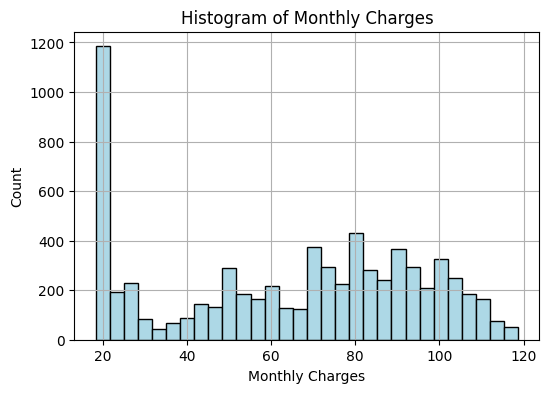

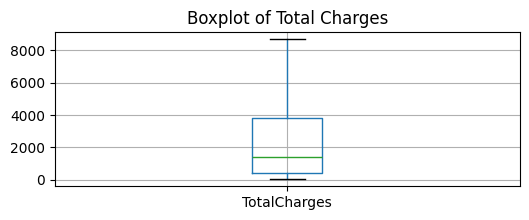


 Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

 Churn Proportion:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [10]:
import matplotlib.pyplot as plt

# Summary statistics for numerical columns
print("Summary statistics:")
print(df1.describe())

# Histogram for MonthlyCharges
plt.figure(figsize=(6,4))
df1['MonthlyCharges'].hist(bins=30, color='lightblue', edgecolor='black')
plt.title("Histogram of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

# Boxplot for TotalCharges
plt.figure(figsize=(6,2))
df1.boxplot(column='TotalCharges')
plt.title("Boxplot of Total Charges")
plt.show()

# Churn count and proportion
print("\n Churn Count:")
print(df1['Churn'].value_counts())
print("\n Churn Proportion:")
print(df1['Churn'].value_counts(normalize=True))

Tasks 4: Customer Segmentation Visualization

Description:
Visualize customer distribution by tenure
using pie or donut charts. (e.g., 0-12
months, 13-36 months, 37+ months).                            
Use a clustered bar chart to compare
average monthly charges across tenure
categories,
adding annotations to highlight significant
trends.

Skills :
Pie charts
clustered bar charts
interactive visualization.                     
Tools:
Matplotlib, Plotly

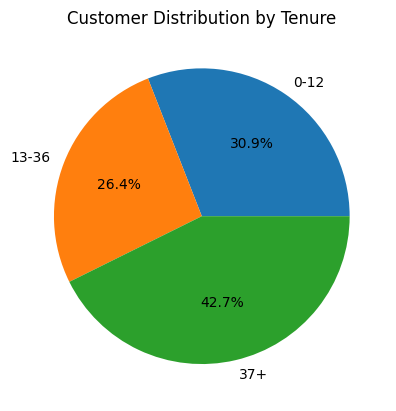

C:\Users\digital\AppData\Local\Temp\ipykernel_7092\1153197098.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_charges = df1.groupby('tenure_bucket')['MonthlyCharges'].mean()


Text(0, 0.5, 'Average Monthly Charges ($)')

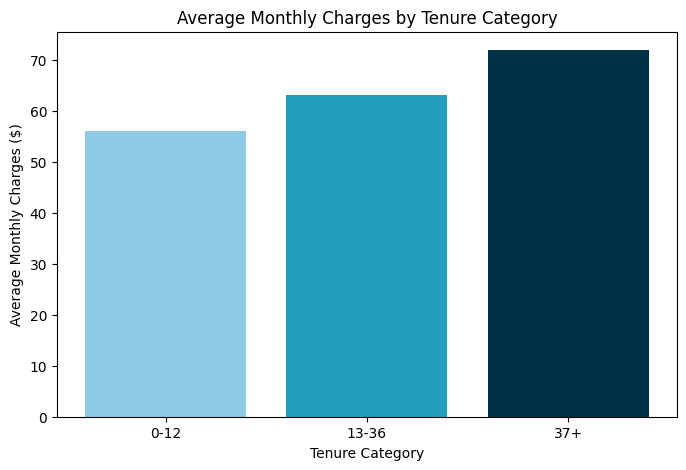

In [12]:
df1['tenure_bucket'] = pd.cut(
    df1['tenure'],
    bins=[0, 12, 36, float('inf')],
    labels=['0-12', '13-36', '37+'],
    right=True
)
tenure_order = ['0-12', '13-36', '37+']

tenure_counts = (
    df1['tenure_bucket']
    .value_counts()
    .reindex(tenure_order)
    .fillna(0)
)

plt.pie(
    tenure_counts.values,
    labels=tenure_counts.index,
    autopct='%1.1f%%'
)
plt.title("Customer Distribution by Tenure")
plt.show()


# Create tenure buckets
df1['tenure_bucket'] = pd.cut(
    df1['tenure'],
    bins=[0, 12, 36, float('inf')],
    labels=['0-12', '13-36', '37+']
)

# Group & calculate average monthly charges
avg_charges = df1.groupby('tenure_bucket')['MonthlyCharges'].mean()

#Plot clustered bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(avg_charges.index, avg_charges.values,color=['#8ecae6','#219ebc','#023047'])

plt.title("Average Monthly Charges by Tenure Category")
plt.xlabel("Tenure Category")
plt.ylabel("Average Monthly Charges ($)")